In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [ ]:
#global style setting

sns.set_theme(style="whitegrid", rc={
    "axes.spines.right": False,
    "axes.spines.top": False
})

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

# Color palette
PALETTE_FINANCIAL = ["#3B82F6", "#F43F5E", "#10B981"]
PALETTE_CHANNEL   = ["#8B5CF6", "#06B6D4"]
COLOR_SINGLE      = "#6366F1"

In [ ]:
# Functions for visualisations

# Forman large axis numbers as 'M' (millions) or 'k' (thousands)
def k_formatter(x, pos):
    if x >= 1_000_000:
        return f"{x / 1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{int(x / 1_000)}k"
    return f"{int(x)}"

#  k_formatter to x- or y-axis of a given Axes object
def apply_k_formatter(ax, axis="y"):
    formatter = FuncFormatter(k_formatter)
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)

#Data Loading and Data Overview

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate

# Uploading datasets
products = pd.read_csv("products.csv")
events = pd.read_csv("events.csv")
countries = pd.read_csv("countries.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate


In [ ]:
print("PRODUCTS")
print(products.head())
print(products.shape)
print(products.info())

PRODUCTS
     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies
(12, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
None


In [ ]:
print("COUNTRIES")
print(countries.head())
print(countries.shape)
print(countries.info())

COUNTRIES
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia
(249, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
None


In [ ]:
print("EVENTS")
print(events.head())
print(events.shape)
print(events.info())

EVENTS
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
(1330, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  

# Data Cleaning and Transformation

In [ ]:
# Standardize column names to snake_case across all tables
countries.columns = countries.columns.str.lower().str.replace("-", "_")
events.columns = events.columns.str.lower().str.replace(" ", "_")

In [ ]:
print("MISSING VALUES \n")
print(f"Products NaN:\n{products.isna().sum()} \n")
print(f"Countries NaN:\n{countries.isna().sum()}\n")
print(f"Events NaN:\n{events.isna().sum()}\n")

MISSING VALUES 

Products NaN:
id           0
item_type    0
dtype: int64 

Countries NaN:
name          0
alpha_2       1
alpha_3       0
region        1
sub_region    1
dtype: int64

Events NaN:
order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         2
unit_price         0
unit_cost          0
dtype: int64



In [ ]:
# Percentage of missed values per column
print(f"Countries NaN %:\n{countries.isna().sum() / countries.shape[0] * 100}\n")
print(f"Events NaN %:\n{events.isna().sum() / events.shape[0] * 100}\n")

Countries NaN %:
name          0.000000
alpha_2       0.401606
alpha_3       0.000000
region        0.401606
sub_region    0.401606
dtype: float64

Events NaN %:
order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64



In the Events table, the missing values in the units_sold column have been removed as the percentage is very low;
however, in the country_code column, missing values account 6.17%—so we cannot simply delete them. We will therefore replace them with ‘Uknown’.

In [ ]:
# Drop rows where 'units_sold' is missing (very small share, <1%)
events = events.dropna(subset = ["units_sold"])

# Fill 'country_code' NaN with 'Unknown' (>5% share — cannot simply drop)
events['country_code'] = events["country_code"].fillna("Unknown")

# Fill missing geographic fields with 'Unknown'
fill_values = {"alpha_2": "Unknown", "region": "Unknown", "sub_region": "Unknown"}
countries.fillna(value=fill_values, inplace=True)

# Add new country - 'Uknown' to Countries table
unknown_country = pd.DataFrame({
    "name": ["Unknown"], "alpha_2": ["Unknown"], "alpha_3": ["Unknown"],
    "region": ["Unknown"], "sub_region": ["Unknown"]
})
countries = pd.concat([countries, unknown_country], ignore_index=True)

In [ ]:
# Confirm no remaining nulls
print(f"Remaining NaN — Countries:{countries.isna().sum().sum()}")
print(f"Remaining NaN — Events:{events.isna().sum().sum()}")

Remaining NaN — Countries:0
Remaining NaN — Events:0


In [ ]:
# Convert date columns from string to datetime
events["order_date"] = pd.to_datetime(events["order_date"])
events["ship_date"]  = pd.to_datetime(events["ship_date"])

print(events.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB
None


In [ ]:
# Inspect raw category values to spot casing/spacing inconsistencies
print(events['order_priority'].value_counts())
print(events['sales_channel'].value_counts())
print(events['country_code'].value_counts())

order_priority
M     352
H     335
L     334
C     304
 C      2
M       1
Name: count, dtype: int64
sales_channel
Offline    665
Online     660
online       3
Name: count, dtype: int64
country_code
Unknown    82
SMR        40
AND        40
ROU        34
UKR        33
BIH        33
RUS        32
MLT        32
GRC        32
MKD        32
CZE        31
SVK        30
BGR        30
NOR        30
CYP        30
ITA        30
IRL        30
ARM        29
SRB        29
SWE        29
AUT        28
MNE        28
BLR        28
LUX        28
CHE        28
POL        28
SVN        27
LVA        27
DEU        26
FRA        26
BEL        26
DNK        26
PRT        25
ESP        25
HUN        25
LTU        25
LIE        24
NLD        24
ISL        23
GEO        23
GBR        23
EST        23
FIN        23
ALB        21
HRV        17
MCO        13
Name: count, dtype: int64


In [ ]:
# Normalize categories values
events['order_priority'] = events['order_priority'].str.upper().str.replace(" ", "")
events['sales_channel'] = events['sales_channel'].str.lower()

print(events['order_priority'].value_counts())
print(events['sales_channel'].value_counts())


order_priority
M    353
H    335
L    334
C    306
Name: count, dtype: int64
sales_channel
offline    665
online     663
Name: count, dtype: int64


In [ ]:
# Check for duplicates
print(f"Duplicates — Products:  {products.duplicated().sum()}")
print(f"Duplicates — Countries: {countries.duplicated().sum()}")
print(f"Duplicates — Events:    {events.duplicated().sum()}")

Duplicates — Products:  0
Duplicates — Countries: 0
Duplicates — Events:    0


In [ ]:
# Check key field uniqueness
print(f"Unique order_id:   {events["order_id"].nunique()}")
print(f"Unique product id: {products["id"].nunique()}")
print(f"Unique alpha_3:    {countries["alpha_3"].nunique()}")

Unique order_id:   1328
Unique product id: 12
Unique alpha_3:    250


In [ ]:
# Check Numeric anomalies
print(events.describe())

           order_id                     order_date  \
count  1.328000e+03                           1328   
mean   5.416231e+08  2013-10-11 22:28:54.939759104   
min    1.006406e+08            2010-01-01 00:00:00   
25%    3.213291e+08            2011-12-14 06:00:00   
50%    5.399925e+08            2013-10-15 12:00:00   
75%    7.547357e+08            2015-08-29 12:00:00   
max    9.998797e+08            2017-07-23 00:00:00   
std    2.573496e+08                            NaN   

                           ship_date   product_id   units_sold   unit_price  \
count                           1328  1328.000000  1328.000000  1328.000000   
mean   2013-11-05 17:22:02.891566336  5787.775602  4952.201807   264.913245   
min              2010-01-10 00:00:00  1270.000000     2.000000     9.330000   
25%              2012-01-02 00:00:00  3127.000000  2356.750000    81.730000   
50%              2013-11-05 12:00:00  5988.000000  4962.000000   154.060000   
75%              2015-10-04 18:00:00  8

# Data analysis and visualization

## Merge Data

In [ ]:
# Join tables into a single DataFrame
events_products = pd.merge(events, products, left_on="product_id", right_on="id" , how="inner")
sales = pd.merge(events_products, countries, left_on="country_code", right_on="alpha_3", how = "left")
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
 10  id              1328 non-null   int64         
 11  item_type       1328 non-null   object        
 12  name            1328 non-null   object        
 13  alpha_2         1328 non-null   object        
 14  alpha_3         1328 non-null   object        
 15  regi

In [ ]:
sales.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha_2,alpha_3,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,online,4693.0,668.27,502.54,7940,Household,Unknown,Unknown,Unknown,Unknown,Unknown
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
# Drop duplicated columns and rename for clarity
sales = sales.drop(['id', 'country_code'], axis=1)
sales = sales.rename(columns={'name':'country_name'})

print(sales.columns)

Index(['order_id', 'order_date', 'ship_date', 'order_priority', 'product_id',
       'sales_channel', 'units_sold', 'unit_price', 'unit_cost', 'item_type',
       'country_name', 'alpha_2', 'alpha_3', 'region', 'sub_region'],
      dtype='object')


In [ ]:
# Company's key financial metrics

# add profit, total cost and revenue calculation columns
sales['revenue'] = sales['units_sold'] * sales['unit_price']
sales['total_cost'] = sales['units_sold'] * sales['unit_cost']
sales['profit'] = sales['revenue'] - sales['total_cost']

# Compute delivery time in days
sales["delivery_time"] = sales["ship_date"] - sales["order_date"]
sales["delivery_days"] = sales["delivery_time"] / pd.Timedelta(days=1)

# Extract time dimensions
sales["year"] = sales["order_date"].dt.year
sales["year_month"] = sales["order_date"].dt.to_period("M").astype(str)
sales["day_name"]   = sales["order_date"].dt.day_name()

## Key metrics

In [ ]:
 print(" KEY BUSINESS METRICS")
print(f"Total orders    : {sales['order_id'].nunique():,}")
print(f"Total revenue   : ${sales['revenue'].sum():,.0f}")
print(f"Total cost      : ${sales['total_cost'].sum():,.0f}")
print(f"Total profit    : ${sales['profit'].sum():,.0f}")
print(f"Countries served: {sales['alpha_3'].nunique() - 1}")   # exclude 'Unknown'

 KEY BUSINESS METRICS
Total orders    : 1,328
Total revenue   : $1,702,129,408
Total cost      : $1,200,694,949
Total profit    : $501,434,459
Countries served: 45


## Analysis by product category

In [ ]:
# Set the format: two decimal places, thousands separator
pd.options.display.float_format = "{:,.2f}".format

In [ ]:
# Financial metrics per product category
category_pivot = pd.pivot_table(
    sales,
    values=["revenue", 'total_cost', 'profit', 'units_sold'],
    index="item_type",
    aggfunc='sum'
    ).reset_index()

print(category_pivot)

          item_type        profit        revenue     total_cost  units_sold
0         Baby Food 53,940,997.16 143,647,587.68  89,706,590.52  562,706.00
1         Beverages  9,601,662.78  29,093,160.85  19,491,498.07  613,133.00
2            Cereal 41,255,034.15  95,791,404.50  54,536,370.35  465,685.00
3           Clothes 43,431,314.40  64,626,552.80  21,195,238.40  591,385.00
4         Cosmetics 92,723,306.17 233,154,825.20 140,431,519.03  533,291.00
5            Fruits  1,425,929.52   5,520,299.76   4,094,370.24  591,672.00
6         Household 72,962,466.77 294,205,199.23 221,242,732.46  440,249.00
7              Meat 30,337,736.00 223,762,018.20 193,424,282.20  530,380.00
8   Office Supplies 77,977,176.25 402,213,995.61 324,236,819.36  617,641.00
9     Personal Care 13,975,410.68  45,579,022.94  31,603,612.26  557,678.00
10           Snacks 27,027,422.40  74,788,612.80  47,761,190.40  490,160.00
11       Vegetables 36,776,002.72  89,746,728.64  52,970,725.92  582,544.00


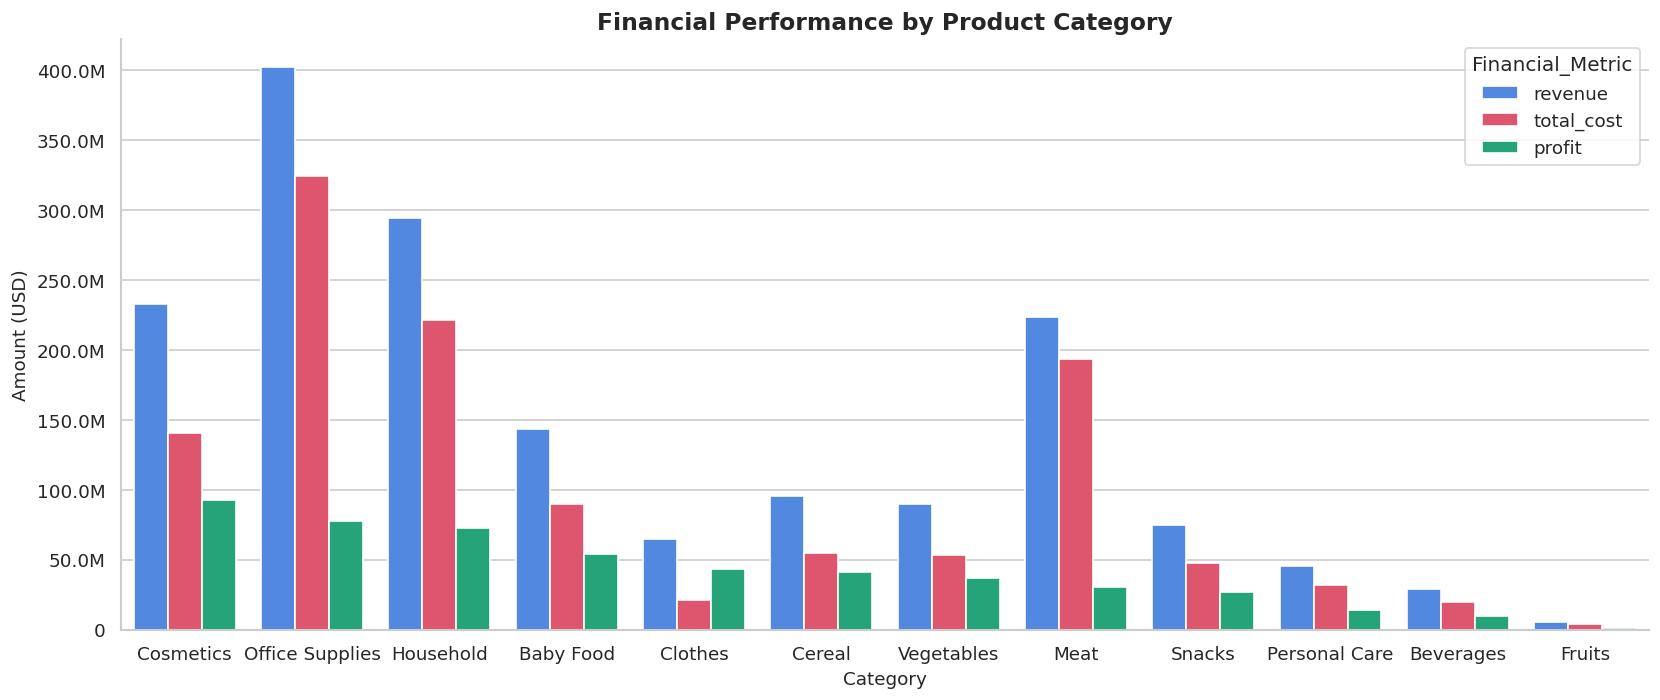

In [ ]:
# Financial performance by product category
categories_melted = pd.melt(
    category_pivot,
    id_vars=['item_type'],
    value_vars=['revenue', 'total_cost', 'profit'],
    var_name='Financial_Metric',
    value_name='Amount'
)
# Sorting categories by profit
sorted_categories = category_pivot.sort_values(by="profit", ascending=False)["item_type"]

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=categories_melted,
    x="item_type", y="Amount",
    hue="Financial_Metric",
    palette=PALETTE_FINANCIAL,
    order= sorted_categories,
    ax=ax
)
ax.set_title("Financial Performance by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Amount (USD)")
apply_k_formatter(ax, "y")

plt.tight_layout()
plt.show()

## Analysis by geography

In [ ]:
# Financial metrics by region and country
geography_pivot = pd.pivot_table(
    sales,
    values=["revenue", "total_cost", "profit", "units_sold"],
    index=["region", "country_name"],
    aggfunc="sum",
    fill_value=0
).reset_index()


print(geography_pivot.head())

   region country_name        profit       revenue    total_cost  units_sold
0    Asia      Armenia  9,422,353.18 37,519,840.21 28,097,487.03  150,665.00
1    Asia       Cyprus 10,032,220.56 33,008,851.50 22,976,630.94  158,743.00
2    Asia      Georgia  5,697,679.21 22,802,195.66 17,104,516.45  101,019.00
3  Europe      Albania 10,490,706.02 32,224,853.87 21,734,147.85   90,608.00
4  Europe      Andorra 15,410,036.63 47,756,693.17 32,346,656.54  185,686.00


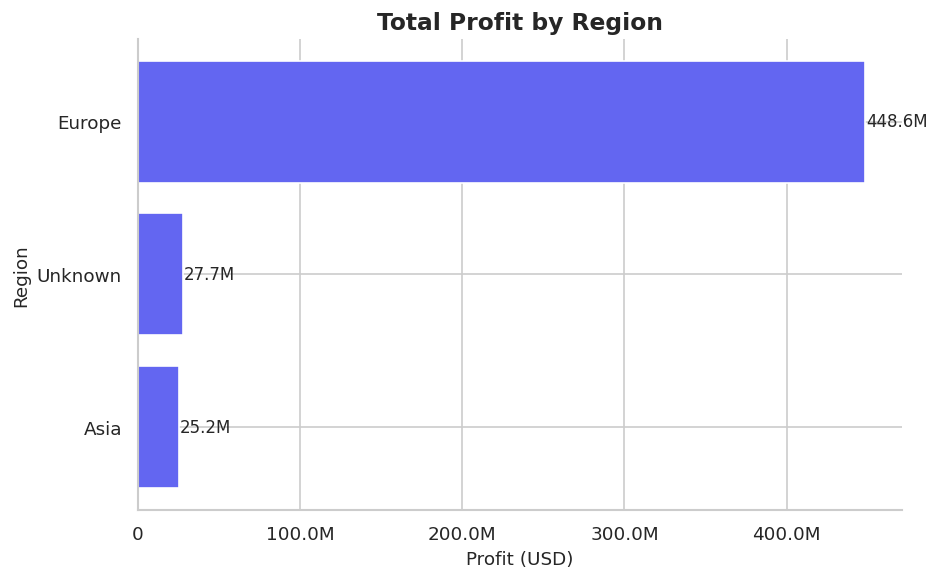

In [ ]:
region_pivot = geography_pivot.groupby("region")[["profit", "revenue"]].sum().reset_index()
region_pivot = region_pivot.sort_values("profit", ascending=True)

# Profit by region
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(region_pivot["region"], region_pivot["profit"], color=COLOR_SINGLE)
for bar in bars:
    ax.text(
        bar.get_width() + 5e5, bar.get_y() + bar.get_height() / 2,
        k_formatter(bar.get_width(), None), va="center", fontsize=10
    )
ax.set_title("Total Profit by Region")
ax.set_xlabel("Profit (USD)")
ax.set_ylabel("Region")
apply_k_formatter(ax, "x")

plt.tight_layout()
plt.show()

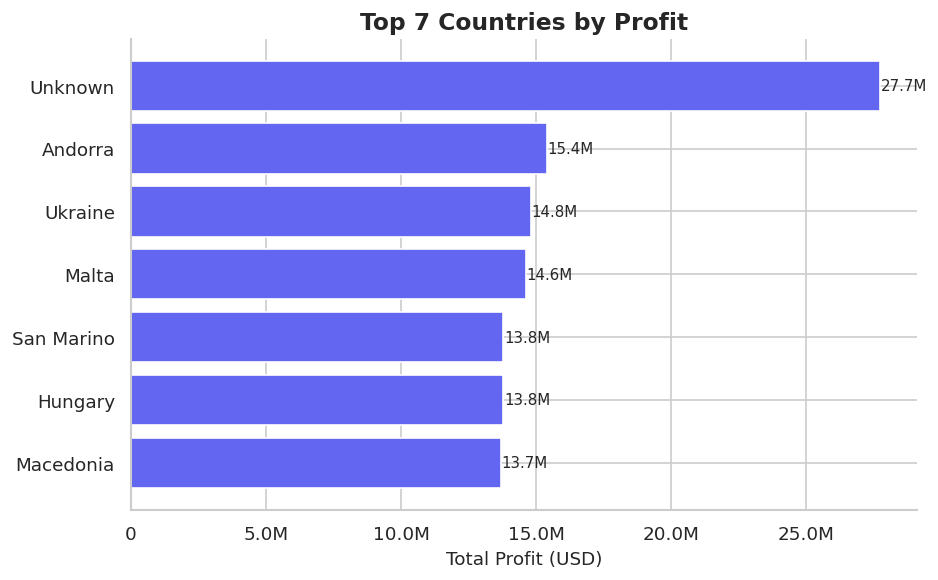

In [ ]:
# Top 7 countries by profit
top7_countries = (
    geography_pivot.groupby("country_name")["profit"]
    .sum()
    .nlargest(7)
    .sort_values()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top7_countries["country_name"], top7_countries["profit"], color=COLOR_SINGLE)
for bar in bars:
    ax.text(
        bar.get_width() + 2e4, bar.get_y() + bar.get_height() / 2,
        k_formatter(bar.get_width(), None), va="center", fontsize=9
    )
ax.set_title("Top 7 Countries by Profit")
ax.set_xlabel("Total Profit (USD)")
ax.set_ylabel("")
apply_k_formatter(ax, "x")
plt.tight_layout()
plt.show()

## Analysis by sales channel

In [ ]:
channel_pivot = pd.pivot_table(
    sales,
    values=["revenue", "total_cost", "profit", "units_sold"],
    index="sales_channel",
    aggfunc="sum"
).reset_index()

print(channel_pivot.head())

  sales_channel         profit        revenue     total_cost   units_sold
0       offline 253,466,518.81 871,760,623.88 618,294,105.07 3,320,363.00
1        online 247,967,940.19 830,368,784.33 582,400,844.14 3,256,161.00


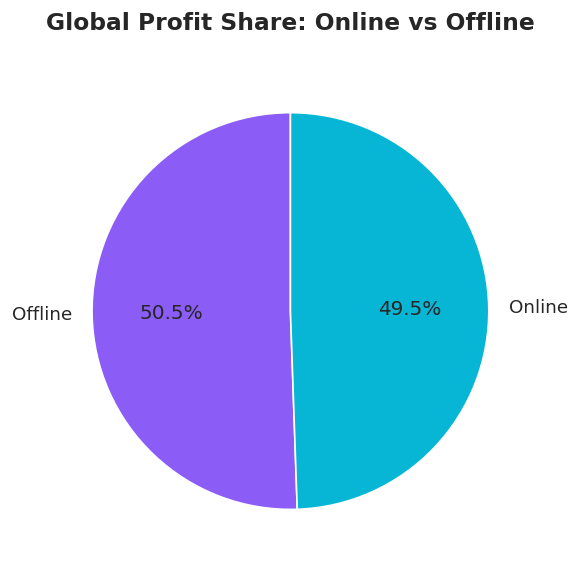

In [ ]:
# Profit share — Online vs Offline
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    channel_pivot["profit"],
    labels=["Offline", "Online"],
    autopct="%1.1f%%",
    startangle=90,
    colors=PALETTE_CHANNEL
)

ax.set_title("Global Profit Share: Online vs Offline", pad=20)

plt.tight_layout()
plt.show()


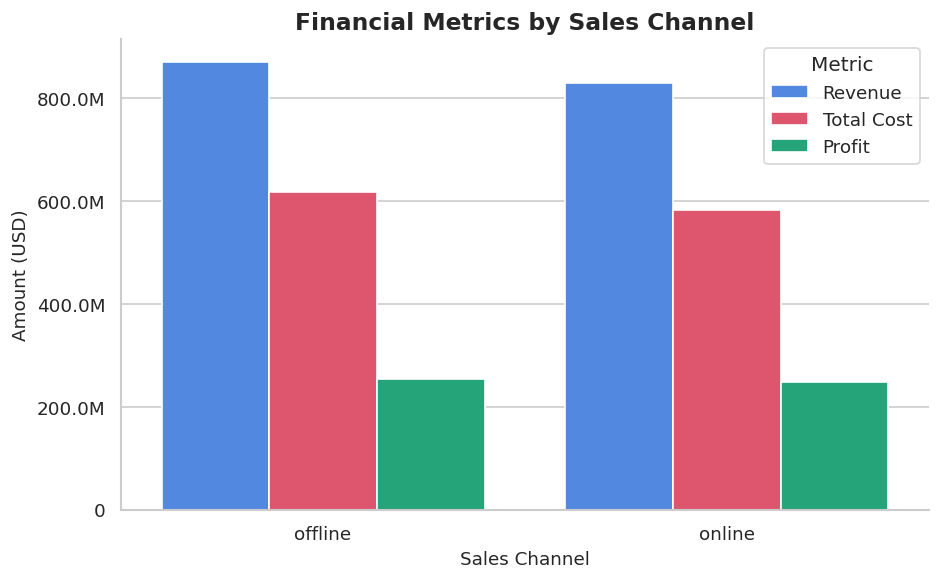

In [ ]:
# Channel comparison — Revenue, Cost, Profit
channel_melted = pd.melt(
    channel_pivot,
    id_vars=["sales_channel"],
    value_vars=["revenue", "total_cost", "profit"],
    var_name="Metric",
    value_name="Amount"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=channel_melted, x="sales_channel", y="Amount",
            hue="Metric", palette=PALETTE_FINANCIAL, ax=ax)
ax.set_title("Financial Metrics by Sales Channel")
ax.set_xlabel("Sales Channel")
ax.set_ylabel("Amount (USD)")
apply_k_formatter(ax, "y")
handles = ax.get_legend().legend_handles
ax.legend(handles, ["Revenue", "Total Cost", "Profit"], title="Metric")
plt.tight_layout()
plt.show()


## Delivery Time Analysis

In [ ]:
# Average delivery time per category, region, and country

delivery_time_category = sales.groupby('item_type')['delivery_time'].mean().reset_index()
delivery_time_region = sales.groupby('region')['delivery_time'].mean().reset_index()
delivery_time_country = sales.groupby('country_name')['delivery_time'].mean().reset_index()

delivery_time_category['delivery_days'] = delivery_time_category['delivery_time'] / pd.Timedelta(days=1)
delivery_time_region['delivery_days'] = delivery_time_region['delivery_time'] / pd.Timedelta(days=1)
delivery_time_country['delivery_days'] = delivery_time_country['delivery_time'] / pd.Timedelta(days=1)


/tmp/ipykernel_25326/1787621612.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars_plot = sns.barplot(


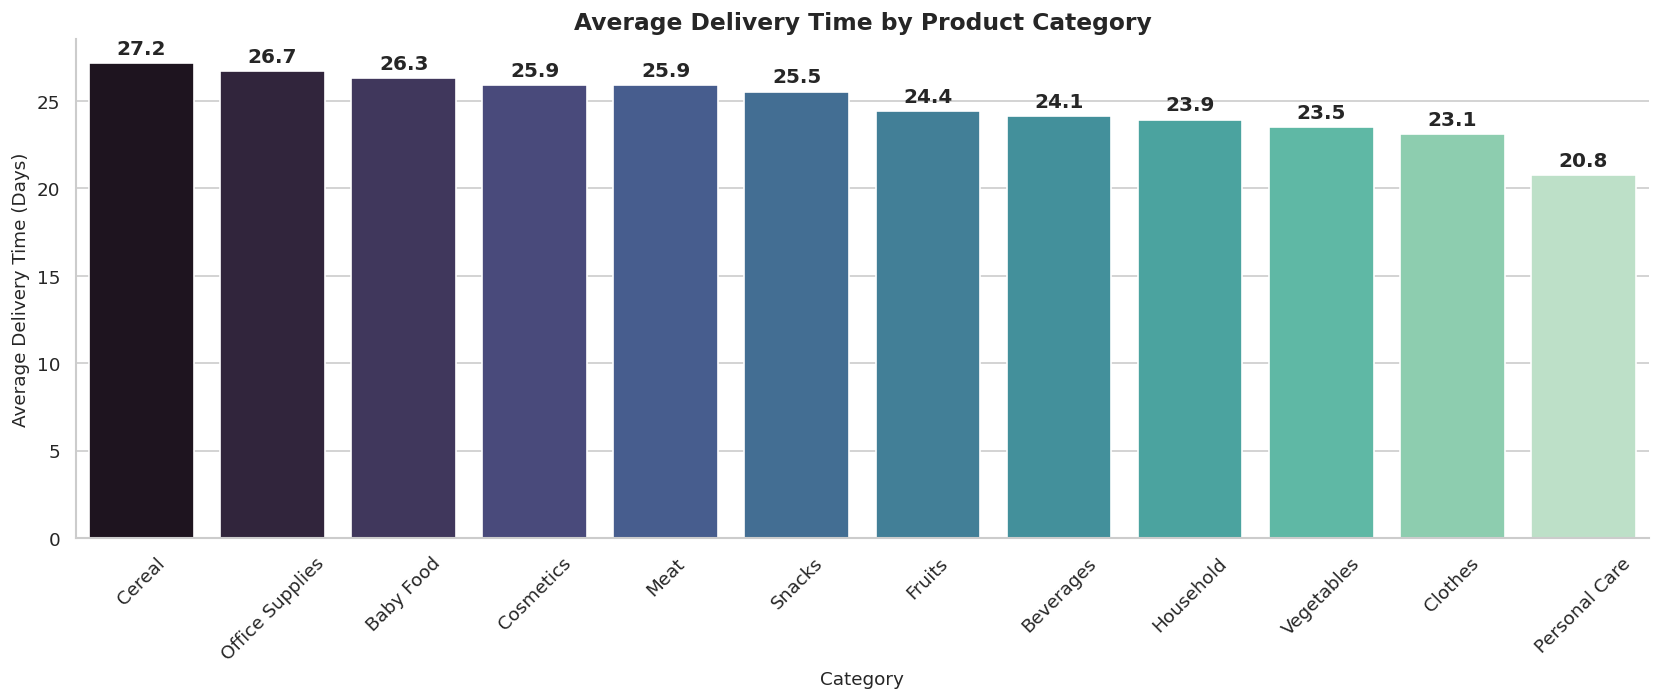

In [ ]:
# Average delivery time by product category

# Sorting categories by delivery time
sorted_categories_by_time = delivery_time_category.sort_values(by="delivery_days", ascending=False)["item_type"]

fig, ax = plt.subplots(figsize=(14, 6))
bars_plot = sns.barplot(
    data=delivery_time_category,
    x="item_type", y="delivery_days",
    palette="mako",
    order= sorted_categories_by_time,
    ax=ax
)
for container in bars_plot.containers:
    bars_plot.bar_label(container, fmt="%.1f", padding=3, fontweight="bold")

ax.set_title("Average Delivery Time by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Average Delivery Time (Days)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

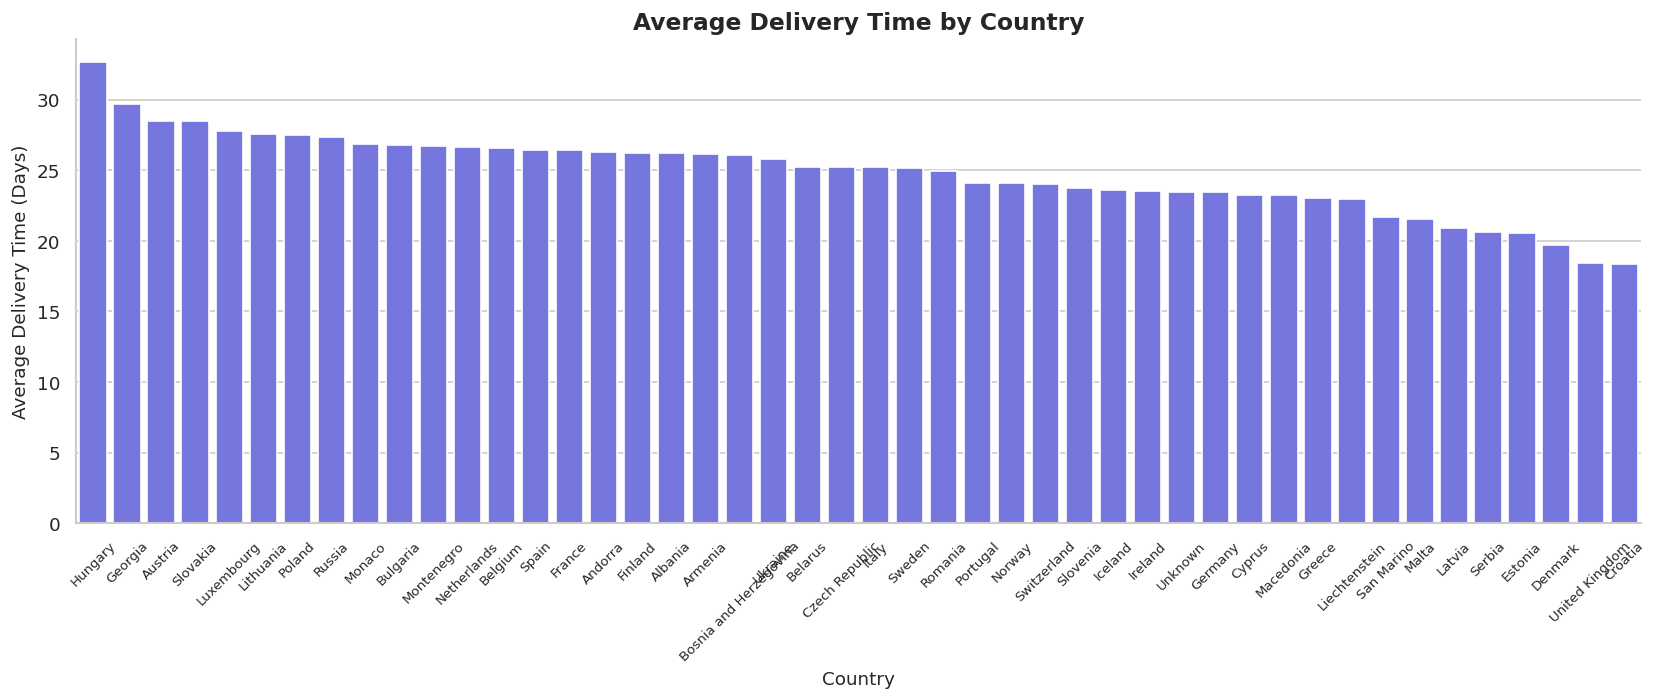

In [ ]:
#Average delivery time by country

# Sorting countries by delivery time
sorted_countries_by_time = delivery_time_country.sort_values(by="delivery_days", ascending=False)["country_name"]

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=delivery_time_country,
    x="country_name", y="delivery_days",
    color=COLOR_SINGLE,
    order=sorted_countries_by_time,
    ax=ax
)
ax.set_title("Average Delivery Time by Country")
ax.set_xlabel("Country")
ax.set_ylabel("Average Delivery Time (Days)")
ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25326/3934393629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  region_plot = sns.barplot(


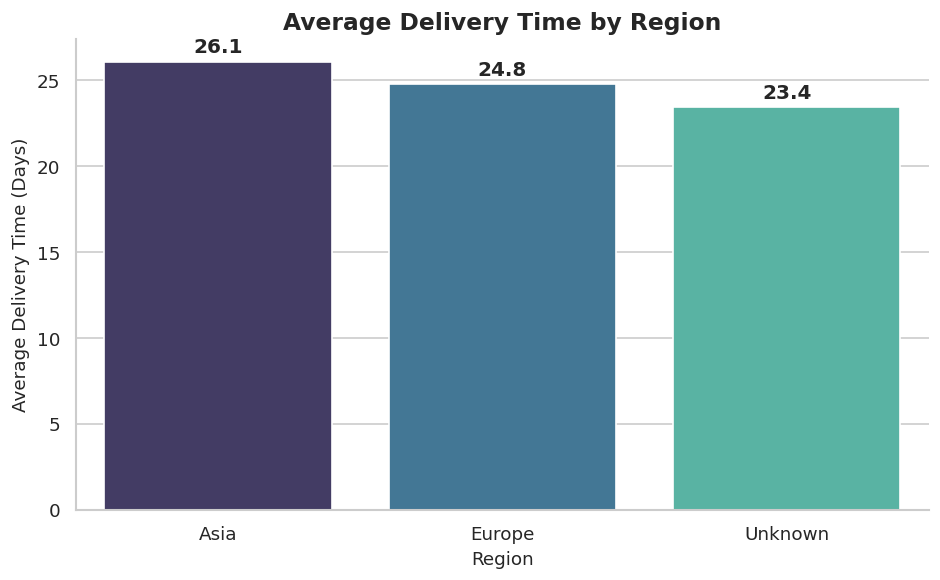

In [ ]:
# Average delivery time by region
fig, ax = plt.subplots(figsize=(8, 5))
region_plot = sns.barplot(
    data=delivery_time_region,
    x="region", y="delivery_days",
    palette="mako", ax=ax
)
for container in region_plot.containers:
    region_plot.bar_label(container, fmt="%.1f", padding=3, fontweight="bold")
ax.set_title("Average Delivery Time by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Average Delivery Time (Days)")

plt.tight_layout()
plt.show()

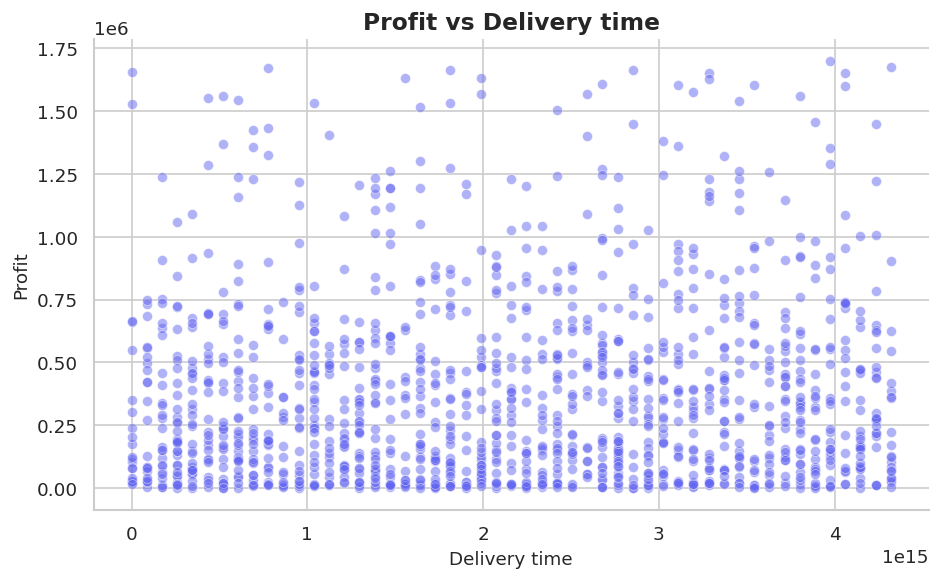

In [ ]:
# Profit vs Delivery time Scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(data=sales, y="profit", x="delivery_time", color= COLOR_SINGLE, alpha = 0.5)

plt.title("Profit vs Delivery time", fontsize=14, fontweight="bold")
plt.xlabel("Delivery time")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()


## Sales trends over time

In [ ]:
# Aggregate units sold by month and segment
sales_category_trend = sales.groupby(['year_month', 'item_type'], as_index=False)['units_sold'].sum()
sales_category_trend= sales_category_trend.sort_values('year_month')
all_dates_cat = sales_category_trend["year_month"].unique()

# Aggregate units sold by year and segment
sales_category_year_trend = sales.groupby(['year', 'item_type'])['units_sold'].sum().reset_index()
sales_category_year_trend = sales_category_year_trend.sort_values('year')
all_years = sales_category_year_trend["year"].unique()

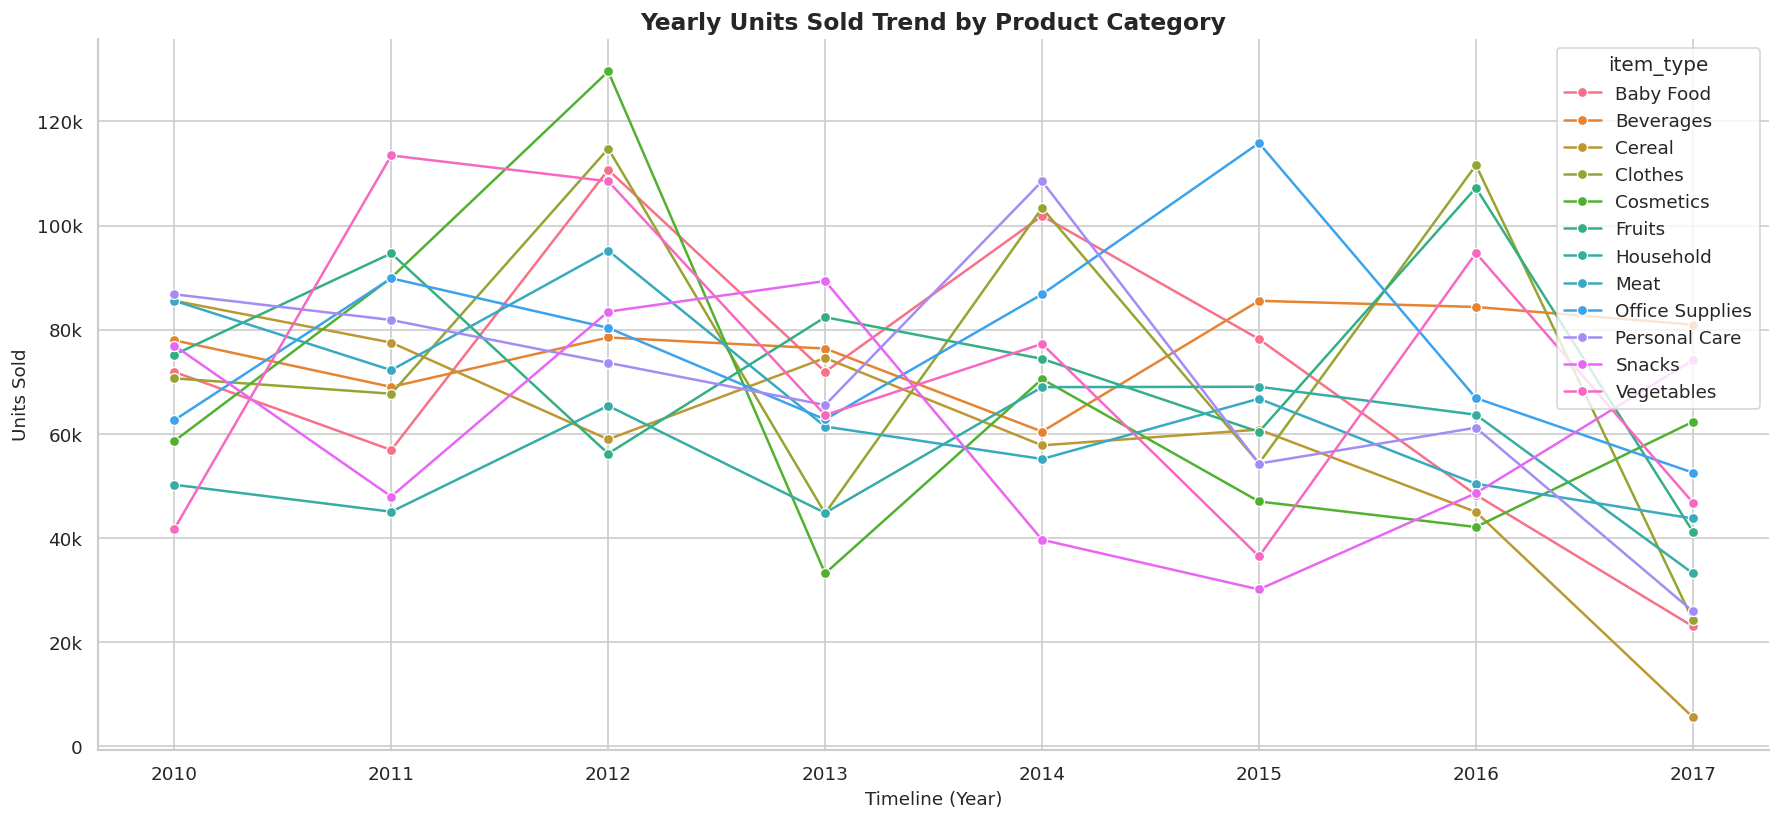

In [ ]:
# Yearly units sold by product category
fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(
    data=sales_category_year_trend,
    x="year", y="units_sold",
    hue="item_type", marker="o", ax=ax
)
ax.set_title("Yearly Units Sold Trend by Product Category")
ax.set_xlabel("Timeline (Year)")
ax.set_ylabel("Units Sold")
ax.set_xticks(all_years)
ax.set_xticklabels(all_years)
apply_k_formatter(ax, "y")

plt.tight_layout()
plt.show()

In [ ]:
# Top-7 countries with the highest sales of all time

top_countries = (
    sales.groupby("country_name")["units_sold"]
    .sum().nlargest(7).index
)
sales_top_countries  = sales[sales["country_name"].isin(top_countries)]
sales_country_trend  = (
    sales_top_countries.groupby(["year", "country_name"])["units_sold"]
    .sum().reset_index()
)
all_dates_country = sales_country_trend["year"].unique()

sales_region_trend = (
    sales.groupby(["year", "region"])["units_sold"]
    .sum().reset_index()
)
all_dates_region = sales_region_trend["year"].unique()


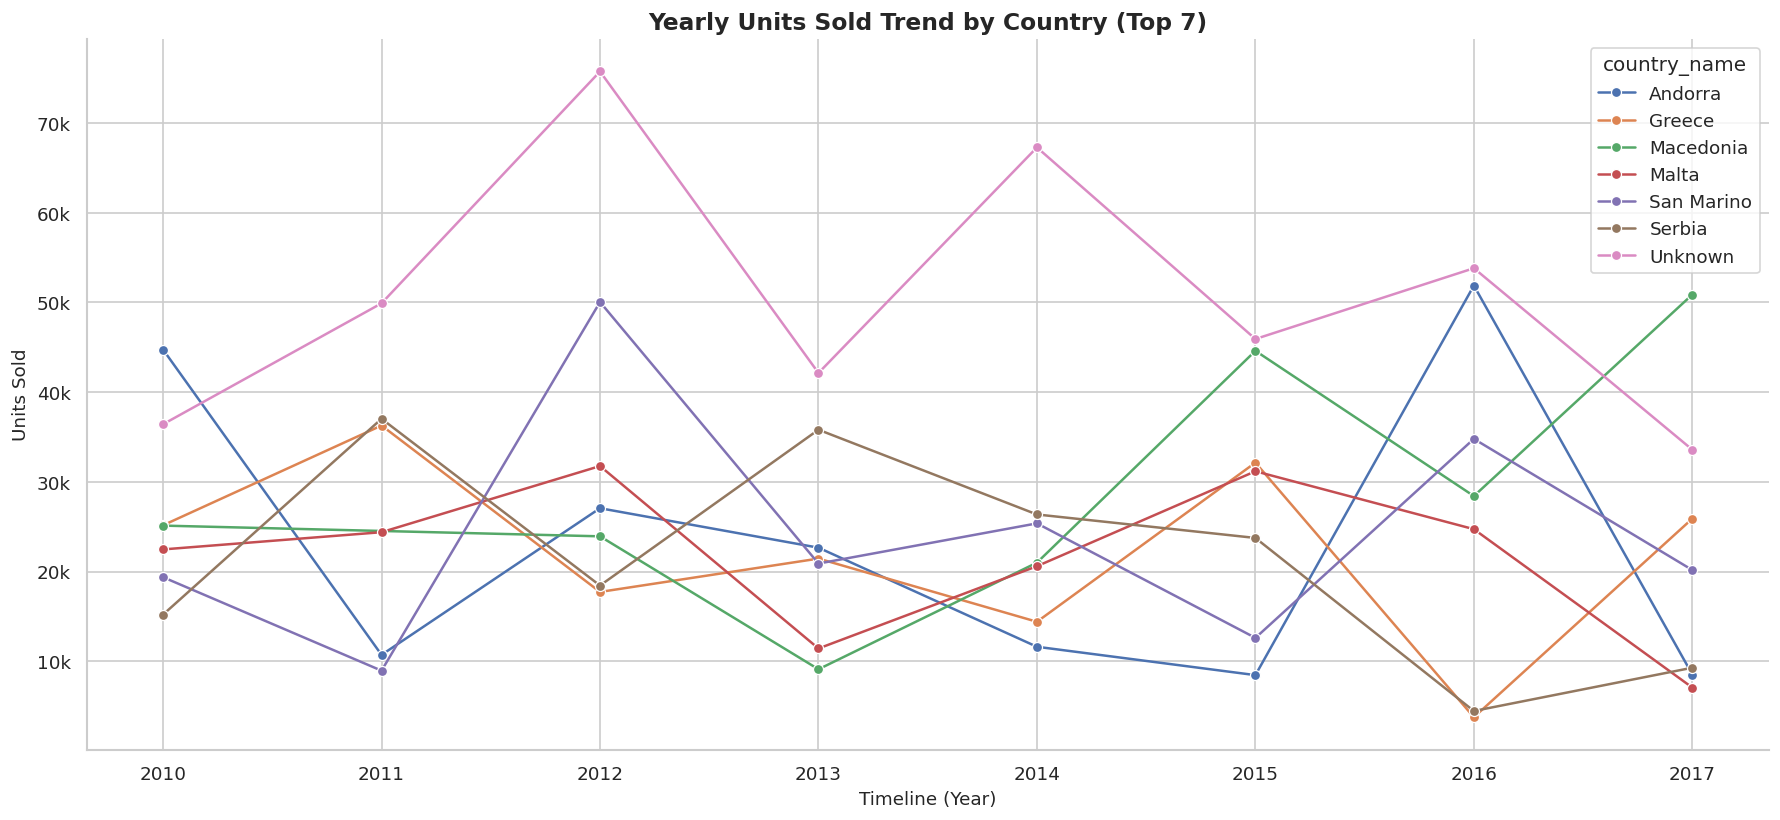

In [ ]:
# Yearly units sold — Top 7 countries

fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(
    data=sales_country_trend,
    x="year", y="units_sold",
    hue="country_name", marker="o", ax=ax
)
ax.set_title("Yearly Units Sold Trend by Country (Top 7)")
ax.set_xlabel("Timeline (Year)")
ax.set_ylabel("Units Sold")
ax.set_xticks(all_years)
ax.set_xticklabels(all_years)
apply_k_formatter(ax, "y")

plt.tight_layout()
plt.show()

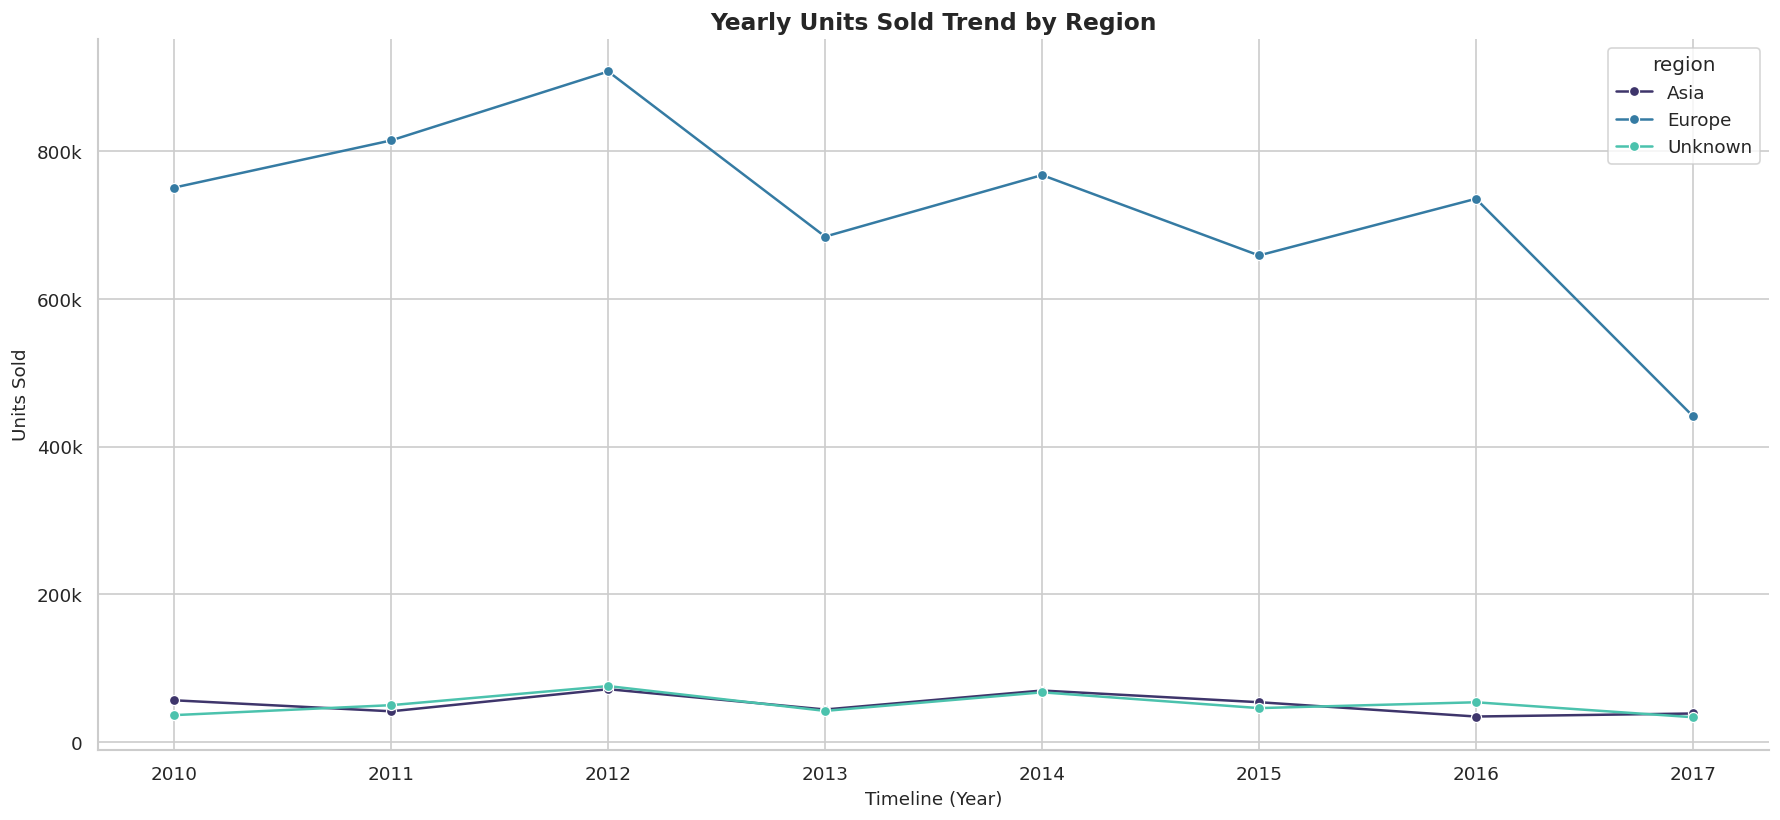

In [ ]:
# Yearly units sold by region
fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(
    data=sales_region_trend,
    x="year", y="units_sold",
    hue="region", marker="o", palette="mako", ax=ax
)
ax.set_title("Yearly Units Sold Trend by Region")
ax.set_xlabel("Timeline (Year)")
ax.set_ylabel("Units Sold")
ax.set_xticks(all_years)
ax.set_xticklabels(all_years)
apply_k_formatter(ax, "y")

plt.tight_layout()
plt.show()

In [ ]:
sales_day = sales.groupby('day_name')['units_sold'].sum().reset_index()
print(sales_day)

    day_name   units_sold
0     Friday   866,387.00
1     Monday 1,027,424.00
2   Saturday 1,015,852.00
3     Sunday 1,051,969.00
4   Thursday   850,351.00
5    Tuesday   863,568.00
6  Wednesday   900,973.00


In [ ]:
# Aggregate units sold by weekday and product category

sales_day_prod = sales.groupby(['day_name', 'item_type'])['units_sold'].sum().reset_index()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sales_day_prod['day_name'] = pd.Categorical(
    sales_day_prod['day_name'], categories=weekday_order, ordered=True
    )
sales_day_prod = sales_day_prod.sort_values('day_name')

print(sales_day_prod)

   day_name        item_type  units_sold
23   Monday       Vegetables  103,622.00
22   Monday           Snacks  107,916.00
21   Monday    Personal Care   66,729.00
20   Monday  Office Supplies   93,941.00
19   Monday             Meat  100,388.00
..      ...              ...         ...
43   Sunday             Meat   55,543.00
44   Sunday  Office Supplies  102,349.00
45   Sunday    Personal Care   83,840.00
47   Sunday       Vegetables  113,999.00
41   Sunday           Fruits  135,750.00

[84 rows x 3 columns]


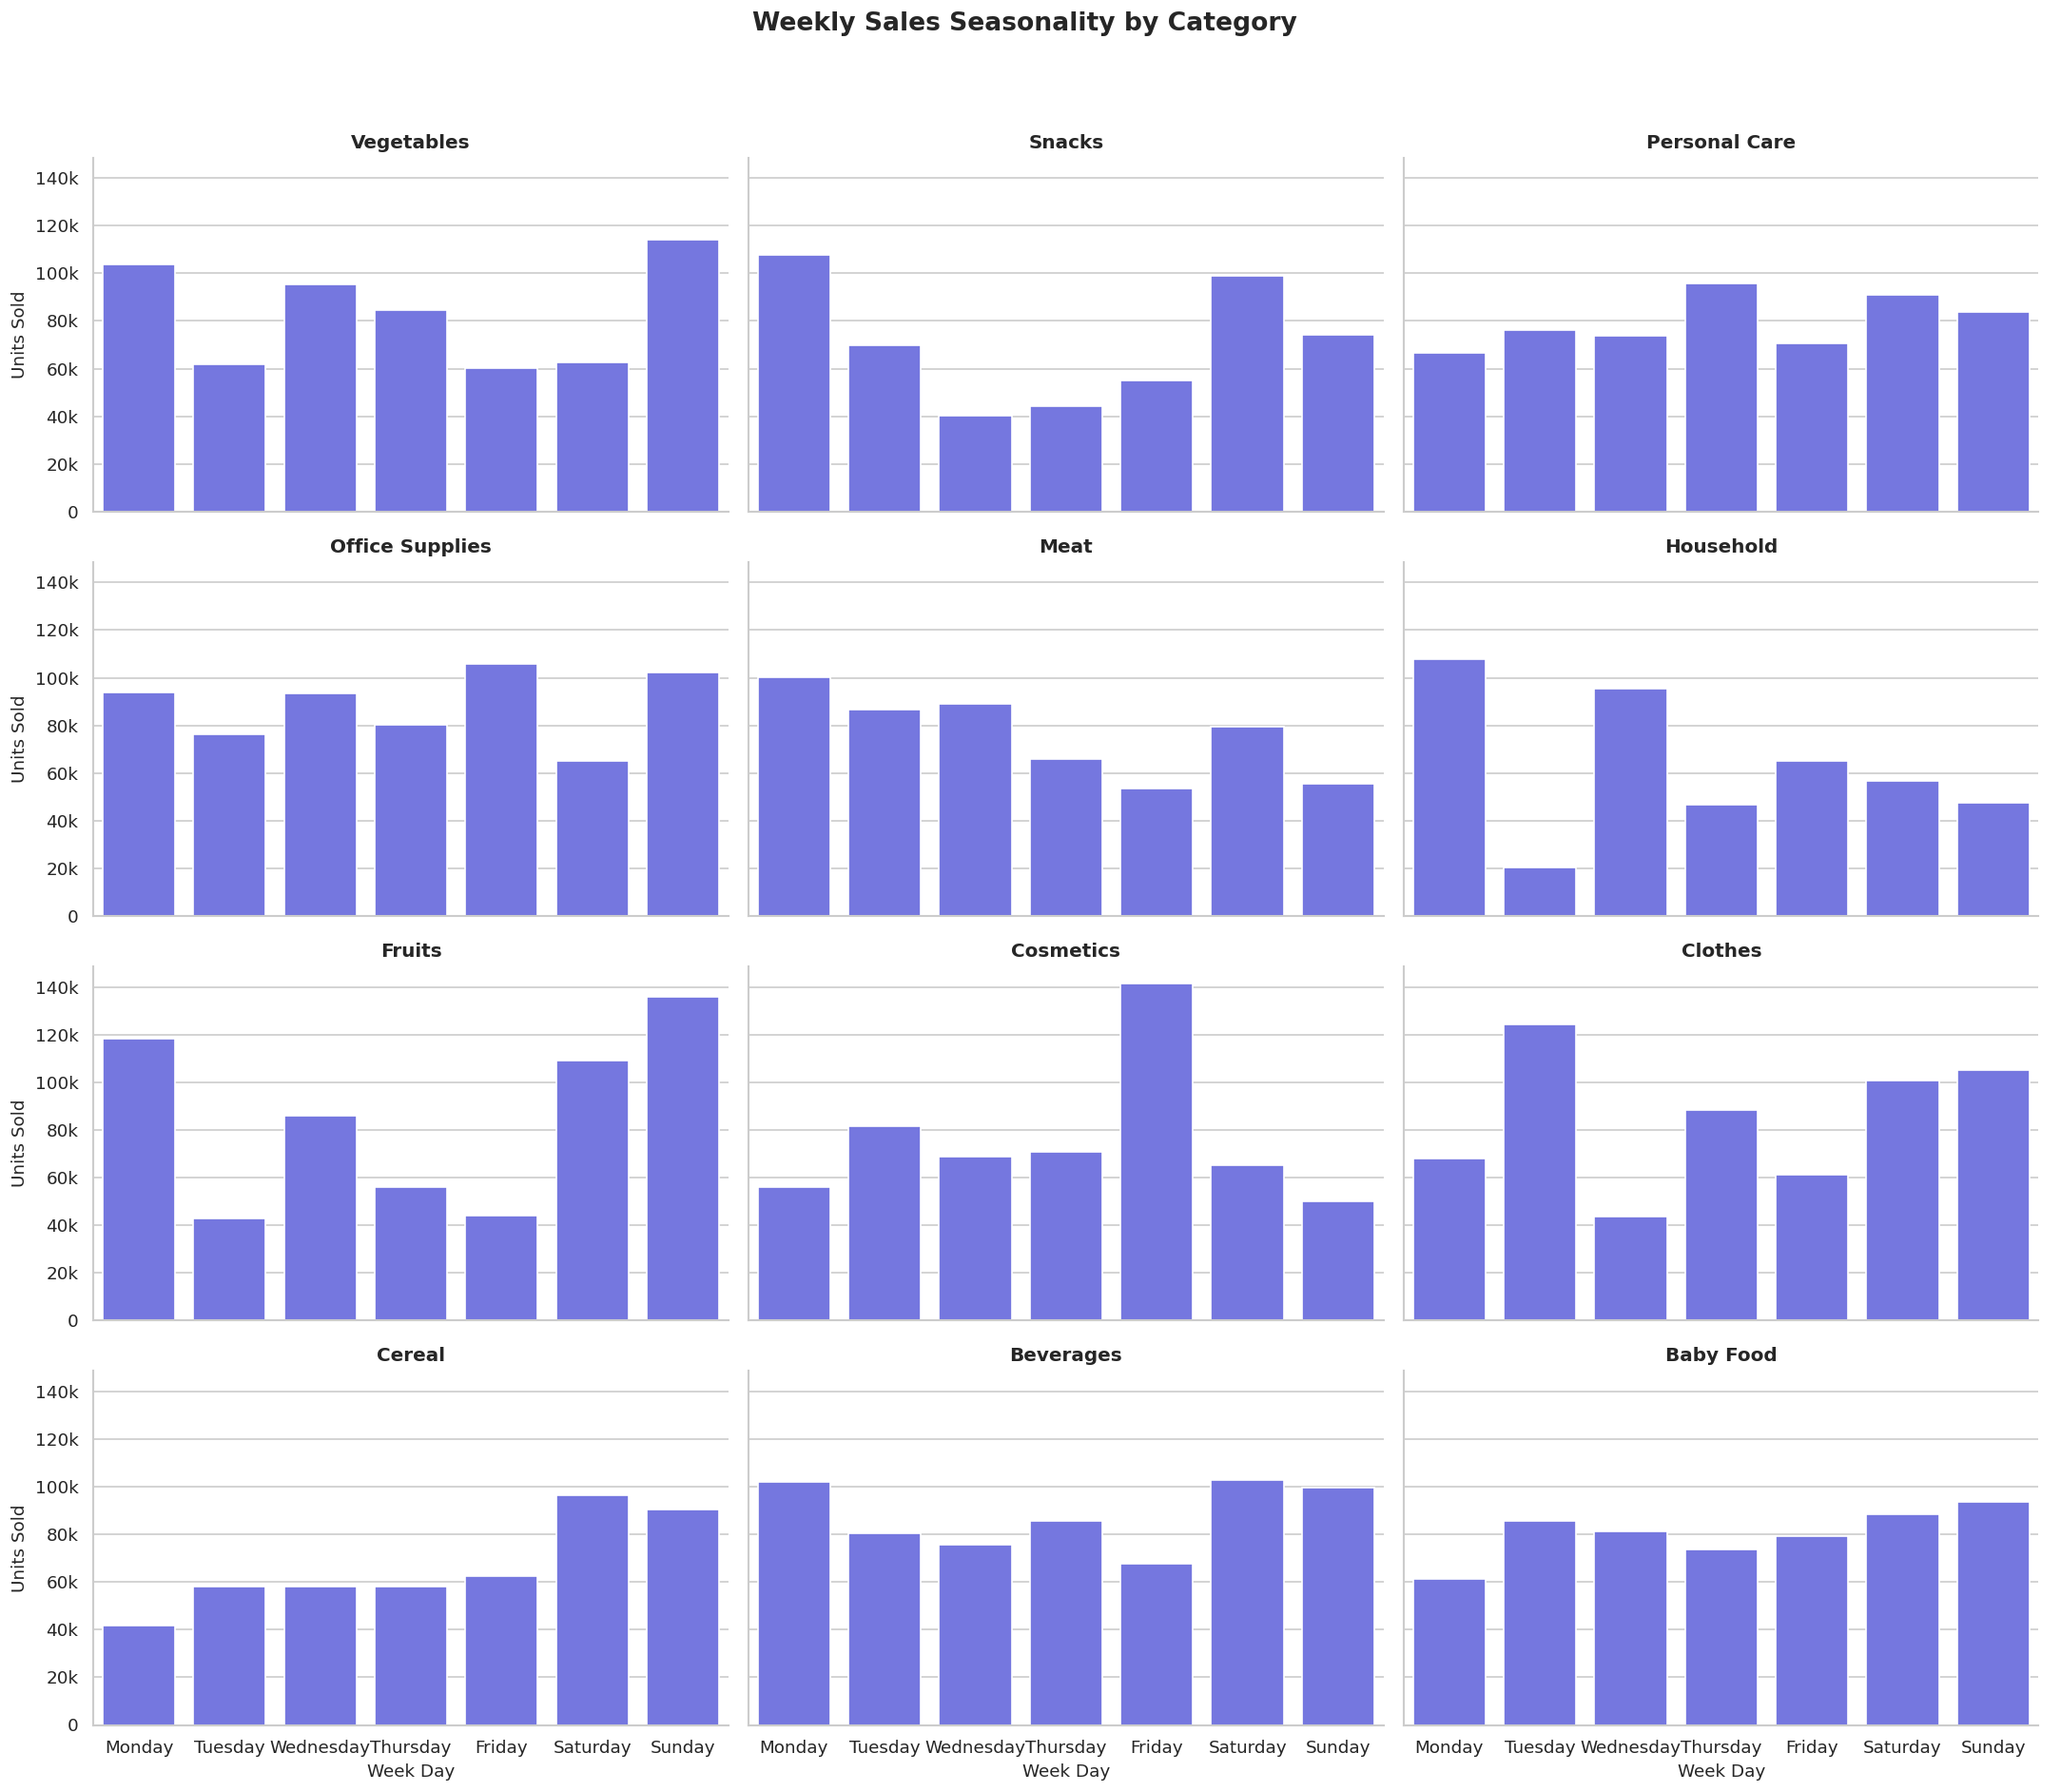

In [ ]:
# Weekly sales seasonality per category

g = sns.catplot(
    data=sales_day_prod,
    kind="bar",
    x="day_name", y="units_sold",
    col="item_type",
    col_wrap=3,
    height=4, aspect=1.5,
    color=COLOR_SINGLE,
    errorbar=None
)
g.set_axis_labels("Week Day", "Units Sold")
for ax in g.axes.flat:
    apply_k_formatter(ax, "y")

    # Clean subplot title — remove 'item_type = ' prefix
    title = ax.get_title().split("=")[-1].strip()
    ax.set_title(title, fontweight="bold", fontsize=12)
plt.tight_layout()

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Weekly Sales Seasonality by Category", fontsize=16, fontweight="bold")
plt.show()

# Conclusions:

A total of **1,328 orders** were processed across **45 countries** during the analysis period. The total revenue reached 1.7 billion, while the **total profit amounted to 501.4 million**.

**Cosmetics, Office Supplies, and Household** products consistently generated the highest profits, whereas Fruits showed the lowest profitability.

**Europe** is the company’s core market and primary revenue driver, dominating sales volume throughout the entire period with monthly sales frequently ranging between 60k and 110k units. **Andorra, Ukraine, and Malta** were identified as the top-performing countries by total profit.

Both Online and Offline sales channels contributed almost equally to overall profit.

The **average delivery time** across all categories and regions ranged between **23 and 26 days**.

Hungary recorded the longest delivery times, while Croatia and the United Kingdom demonstrated the fastest delivery performance.

Among product categories, Personal Care had the shortest delivery times, while Cereals experienced the longest.

Overall, the scatter plot indicates a very **weak relationship between delivery time and profit**, suggesting that delivery duration has minimal impact on profitability.

Following a period of rapid growth between 2011 and 2012, the company's sales entered a stabilization phase, maintaining a consistent baseline over the longer term.
While overall trends show no aggressive upward or downward shifts post-2012, individual product categories—most notably Cosmetics, Household, Office Supplies, and Beverages—exhibit strong volatility, characterized by periodic and significant spikes in demand.

Most product categories maintain relatively stable weekday sales, with slight increases observed between **Saturday and Monday**.


The business demonstrates strong financial performance and a well-diversified sales structure, with Europe serving as the primary revenue-driving market. However, the analysis reveals several strategic improvement areas, including reducing dependence on the European market, stabilizing highly volatile product categories, improving low-performing segments, and optimizing logistics in countries with slower delivery times.
